# Proyecto: Predicción del impacto de una publicación de empleo

## Introducción

El lenguaje forma una parte central dentro de nuestro sistema de comuicación y la forma en que comuicamos a otras personas un concepto o idea puede influir directamente en sus acciones o decisiones. A la hora de elegir aplicar a un empleo, en el momento preciso en que una persona debe enviar la solicitud, esta generalmente se encuentra con una publicación de empleo escrita. Estas publicaciones suelen ser muy diversas en cuanto a su estructura del lenguaje, de modo que es posible que la forma en la que está escrita la publicación impacte directamente en la decisión de aplicar o no aplicar al empleo.

Objetivo general: Realizar un análisis del lenguaje mediante herramientas de NLP para establecer un modelo de predicción que determine si la publicación de empleo generará un alto o un bajo número de aplicaciones

Objetivos específicos:
 - Evaluar si las publicaciones de empleo tienen variedad en cuanto a la cantidad de aplicaciones que reciben.
 - Usar herramientas de NLP para establecer si existen patrones diferentes en la estructura del lenguaje entre aquellas publicaciones con una alta cantidad de aplicaciones y aquellas con baja cantidad de aplicaciones.
 - Usar una red neuronal para crear un modelo que permita predecir si una publicación tendrá una alta cantidad de aplicaciones en función de su contenido.


Fuente del dataset: se usó un dataset de publicaciones de empleo scrapeadas por un usuario en linkeding que se encuentra en kaggle (https://www.kaggle.com/datasets/arshkon/linkedin-job-postings). Este dataset contiene una enorme cantidad de features que se encuentran agrupadas en tablas siguiendo un modelo relacional, entre las que se encuentran las descripciones de empleo, la cantidad de visualizaciones que recibó la publicación, la cantidad de personas que aplicaron al empleo, la hora en formato unix time en que se publicó el empleo, y la hora en formato unix time en que el creador del dataset registró el número de aplicaciones y/o visitas mediante el scraping, también en formato unix time. Previamente, durante mi curso de data analytics, realicé una primera aproximación al dataset y calculé el número de aplicaciones/hora y visitas/hora usando la diferencia de tiempo entre que se publicó el empleo y se registró el valor (https://github.com/AgusDRizzo/Proyecto_Data_Analytics). En este caso exporté una parte de ese dataset ya pre-procesado para continuar con este proyecto actual.

In [ ]:
import pandas as pd
import numpy as np

# Importacion del dataset

In [ ]:
df_original = pd.read_csv("C:/Users/agus_/OneDrive/Documentos/Curso_Deep_Learning_NLP/data_preyecto_final_NLP.csv")
df = df_original.copy()

In [ ]:
df = df.rename(columns={"Suma de aplicaciones_hora":"aplicaciones_hora", "Suma de Visitas_hora":"visitas_hora", "Suma de Horas_transcurridas":"horas_transcurridas", "Suma de Salario/hora":"salario_hora", "Suma de Count":"cantidad_beneficios" })

# Data Cleaning

In [ ]:
# Me quedo con publicaciones de empleo en las que hayan transcurrido entre 6 y 12 horas desde que se realizó la publicación y se tomó la medida de la
# cantidad de visitas y aplicaciones. De esta forma hacemos que el tiempo en que se registró la medición sea más homogéneo, ni demasiado corto ni demasiado largo. Quedan 5532 registros
df = df[(df["horas_transcurridas"]>=6) & (df["horas_transcurridas"]<=12)]

In [ ]:
df["aplicaciones_hora"] = df["aplicaciones_hora"].str.replace(",", ".")
df["visitas_hora"] = df["visitas_hora"].str.replace(",", ".")
df["salario_hora"] = df["salario_hora"].str.replace(",", ".")
df["visitas_hora"].fillna(0.00, inplace=True)
df["aplicaciones_hora"].fillna(0.00, inplace=True)
df["salario_hora"].fillna(0.00, inplace=True)
df["cantidad_beneficios"].fillna(0, inplace=True)

C:\Users\agus_\AppData\Local\Temp\ipykernel_13044\3163792807.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["visitas_hora"].fillna(0.00, inplace=True)
C:\Users\agus_\AppData\Local\Temp\ipykernel_13044\3163792807.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [ ]:
df["aplicaciones_hora"] = df["aplicaciones_hora"].astype(float)
df["visitas_hora"] = df["visitas_hora"].astype(float)
df["salario_hora"] = df["salario_hora"].astype(float)
df["cantidad_beneficios"] = df["cantidad_beneficios"].astype(object)

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Funcion iqr para la deteccion de outliers.
def iqr_outlier(x,factor):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    min_ = q1 - factor * iqr
    max_ = q3 + factor * iqr
    result_ = pd.Series([0] * len(x))
    result_[((x < min_) | (x > max_))] = 1
    return result_

In [ ]:
# Creo un diccionario que contiene como clave lel nombre de la variable numérica y como valor una serie en la que los registros con valor 1 corresponden a outliers.

df.reset_index(drop=True, inplace=True)
dic_outliers = {}
for i in ["aplicaciones_hora", "visitas_hora"]:
    outliers = iqr_outlier(df[i], 1.5)
    dic_outliers.update({str(i):outliers})



In [ ]:
# Creo un diccionario que contiene los indices de aquellos registros que continenen outliers.
dic_indices_outliers = {}
for i in ["aplicaciones_hora", "visitas_hora"]:
    out = dic_outliers[i]
    out = out.index[out==1].tolist()
    dic_indices_outliers.update({str(i):out})


In [ ]:
#Cuantifico cuantos outliers hay por variable
for key in dic_indices_outliers:
    print(f'{key}:  {len(dic_indices_outliers[key])}')


aplicaciones_hora:  784
visitas_hora:  642


In [ ]:
outliers_comun = list(set(dic_indices_outliers["aplicaciones_hora"]).intersection(dic_indices_outliers["visitas_hora"]))
outliers_distintos = set(dic_indices_outliers["aplicaciones_hora"]).symmetric_difference(set(dic_indices_outliers["visitas_hora"]))
outliers_eliminar = list(outliers_comun) + list(outliers_distintos)

In [ ]:
df.drop(index=outliers_eliminar, inplace = True)

In [ ]:
#Quedan 4645 registros
len(df)


4645

In [ ]:
df["visitas_hora"].describe()

count    4645.000000
mean        1.021376
std         1.435757
min         0.000000
25%         0.020000
50%         0.320000
75%         1.490000
max         7.230000
Name: visitas_hora, dtype: float64

In [ ]:
df["aplicaciones_hora"].describe()

count    4645.000000
mean        0.124164
std         0.218245
min         0.000000
25%         0.000000
50%         0.000000
75%         0.160000
max         1.000000
Name: aplicaciones_hora, dtype: float64

c:\Users\agus_\miniconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\agus_\miniconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='aplicaciones_hora', ylabel='Count'>

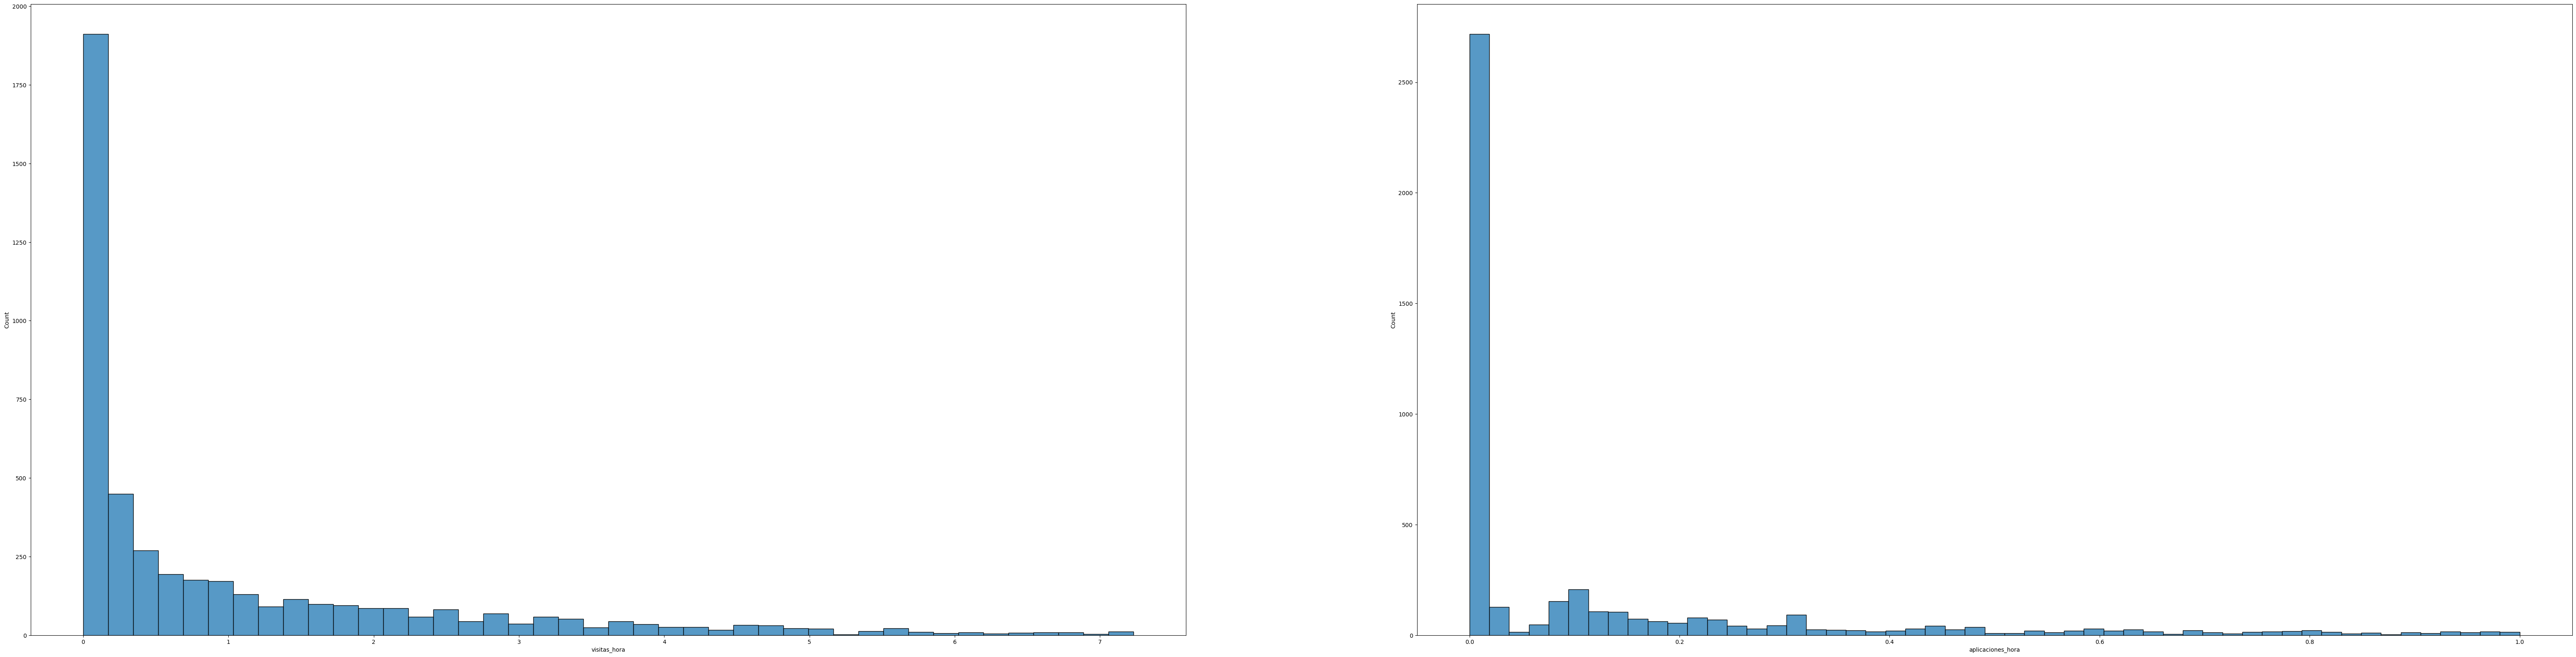

In [ ]:
f, axs = plt.subplots(1, 2, figsize=(80, 20), gridspec_kw=dict(width_ratios=[5, 5]))
sns.histplot(data=df["visitas_hora"], ax=axs[0])
sns.histplot(data=df["aplicaciones_hora"], ax=axs[1])


### Observamos que las distribuciones de las aplicaciones/hora y las visitas/hora no siguen una distribución normal, sino que hay una ayoría acumulada con 0 aplicaciones y/o 0 visitas.

In [ ]:
#Creo una nueva columna dividiendo la cantidad de aplicaciones/hora por la cantidad de visitas/hora. Esta métrica nos da una idea de la
# capacidad que tiene la publicación de empleo apra trasnformar una visita en una aplicación. Es una medida más real del impacto de la publicación.
df["aplicaciones_visita"] = df["aplicaciones_hora"]/df["visitas_hora"]

In [ ]:
# En la nueva columna, aquellos valores que surgen de registros con 0 visitas quedaron como valores nulos porque no es posible dividir por 0.
# Relleno esos valores faltantes con el numero 0.
df["aplicaciones_visita"].fillna(0, inplace=True)

C:\Users\agus_\AppData\Local\Temp\ipykernel_13044\889803229.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["aplicaciones_visita"].fillna(0, inplace=True)


c:\Users\agus_\miniconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='aplicaciones_visita', ylabel='Count'>

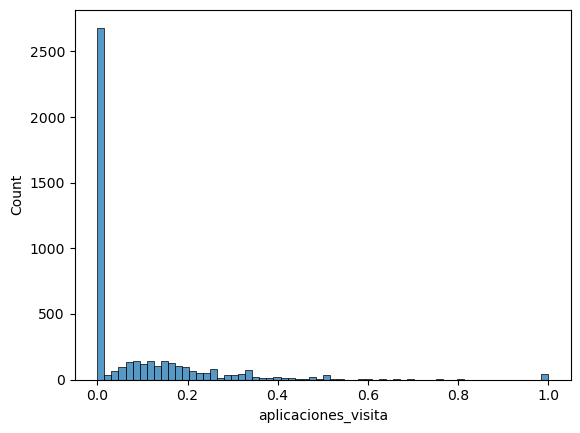

In [ ]:
sns.histplot(data=df["aplicaciones_visita"])


In [ ]:
#Creo una nueva columna basada en la cantidad de aplicaciones/visita de la publicación de empleo. Asumo que aquellas que tengan
# un valor mayor a 0.1 (es decir, cada 10 visitas 1 aplicación) son publicaciones de alto impacto. La columna puede tomar entonces 2 categóricos
# de impacto: impacto alto o bajo. Esta será nuestra variable target: 1 para indicar publicaciones de impacto alto y 0 para indicar publicaciones
# de impacto bajo.
condiciones = [(df["aplicaciones_visita"] >= 0.1), (df["visitas_hora"] < 0.1)]
valores = [1, 0]
df["impacto"] = np.select(condiciones, valores)

# Procesamiento del lenguaje natural (NLP)

## Procederemos a usar herramientas de lenguaje natural para explorar el dataset y encontrar patrones del lenguaje que se asocien con el imapacto de la publicación.

In [ ]:
import nltk
import spacy


In [ ]:
nlp = spacy.load("en_core_web_md")

In [ ]:
textos_alto = df[df["impacto"]==1]["description"]
textos_bajo = df[df["impacto"]==0]["description"]

In [ ]:
# Creamos un bucle para calcular la cantidad de palabras y la cantidad de oraciones de cada texto, para aquellos de alto impacto y para aquellos de bajo impacto.
lista_oraciones_alto = []
lista_palabras_alto = []
lista_palabras_por_oracion_alto = []
for publicacion in textos_alto:
    texto = nlp(publicacion)
    oraciones = list(texto.sents)
    cantidad_oraciones = len(oraciones)
    cantidad_palabras = len([token.text for token in texto])

    # for oracion in oraciones:
    #     palabras = [token.text for token in oracion]
    #     cantidad_palabras += len(palabras)

    promedio_palabras_oracion = cantidad_palabras / cantidad_oraciones
    lista_oraciones_alto.append(cantidad_oraciones)
    lista_palabras_alto.append(cantidad_palabras)
    lista_palabras_por_oracion_alto.append(promedio_palabras_oracion)

df_texto_alto = {"cantidad_oraciones":lista_oraciones_alto, "cantidad_palabras":lista_palabras_alto, "promedio_palabras_oracion":lista_palabras_por_oracion_alto}
df_texto_alto = pd.DataFrame.from_dict(df_texto_alto)

In [ ]:
lista_oraciones_bajo = []
lista_palabras_bajo = []
lista_palabras_por_oracion_bajo = []
for publicacion in textos_bajo:
    texto = nlp(publicacion)
    oraciones = list(texto.sents)
    cantidad_oraciones = len(oraciones)
    cantidad_palabras = 0
    cantidad_palabras = len([token.text for token in texto])

    # for oracion in oraciones:
    #     palabras = [token.text for token in oracion]
    #     cantidad_palabras += len(palabras)

    promedio_palabras_oracion = cantidad_palabras / cantidad_oraciones
    lista_oraciones_bajo.append(cantidad_oraciones)
    lista_palabras_bajo.append(cantidad_palabras)
    lista_palabras_por_oracion_bajo.append(promedio_palabras_oracion)

df_texto_bajo = {"cantidad_oraciones":lista_oraciones_bajo, "cantidad_palabras":lista_palabras_bajo, "promedio_palabras_oracion":lista_palabras_por_oracion_bajo}
df_texto_bajo = pd.DataFrame.from_dict(df_texto_bajo)

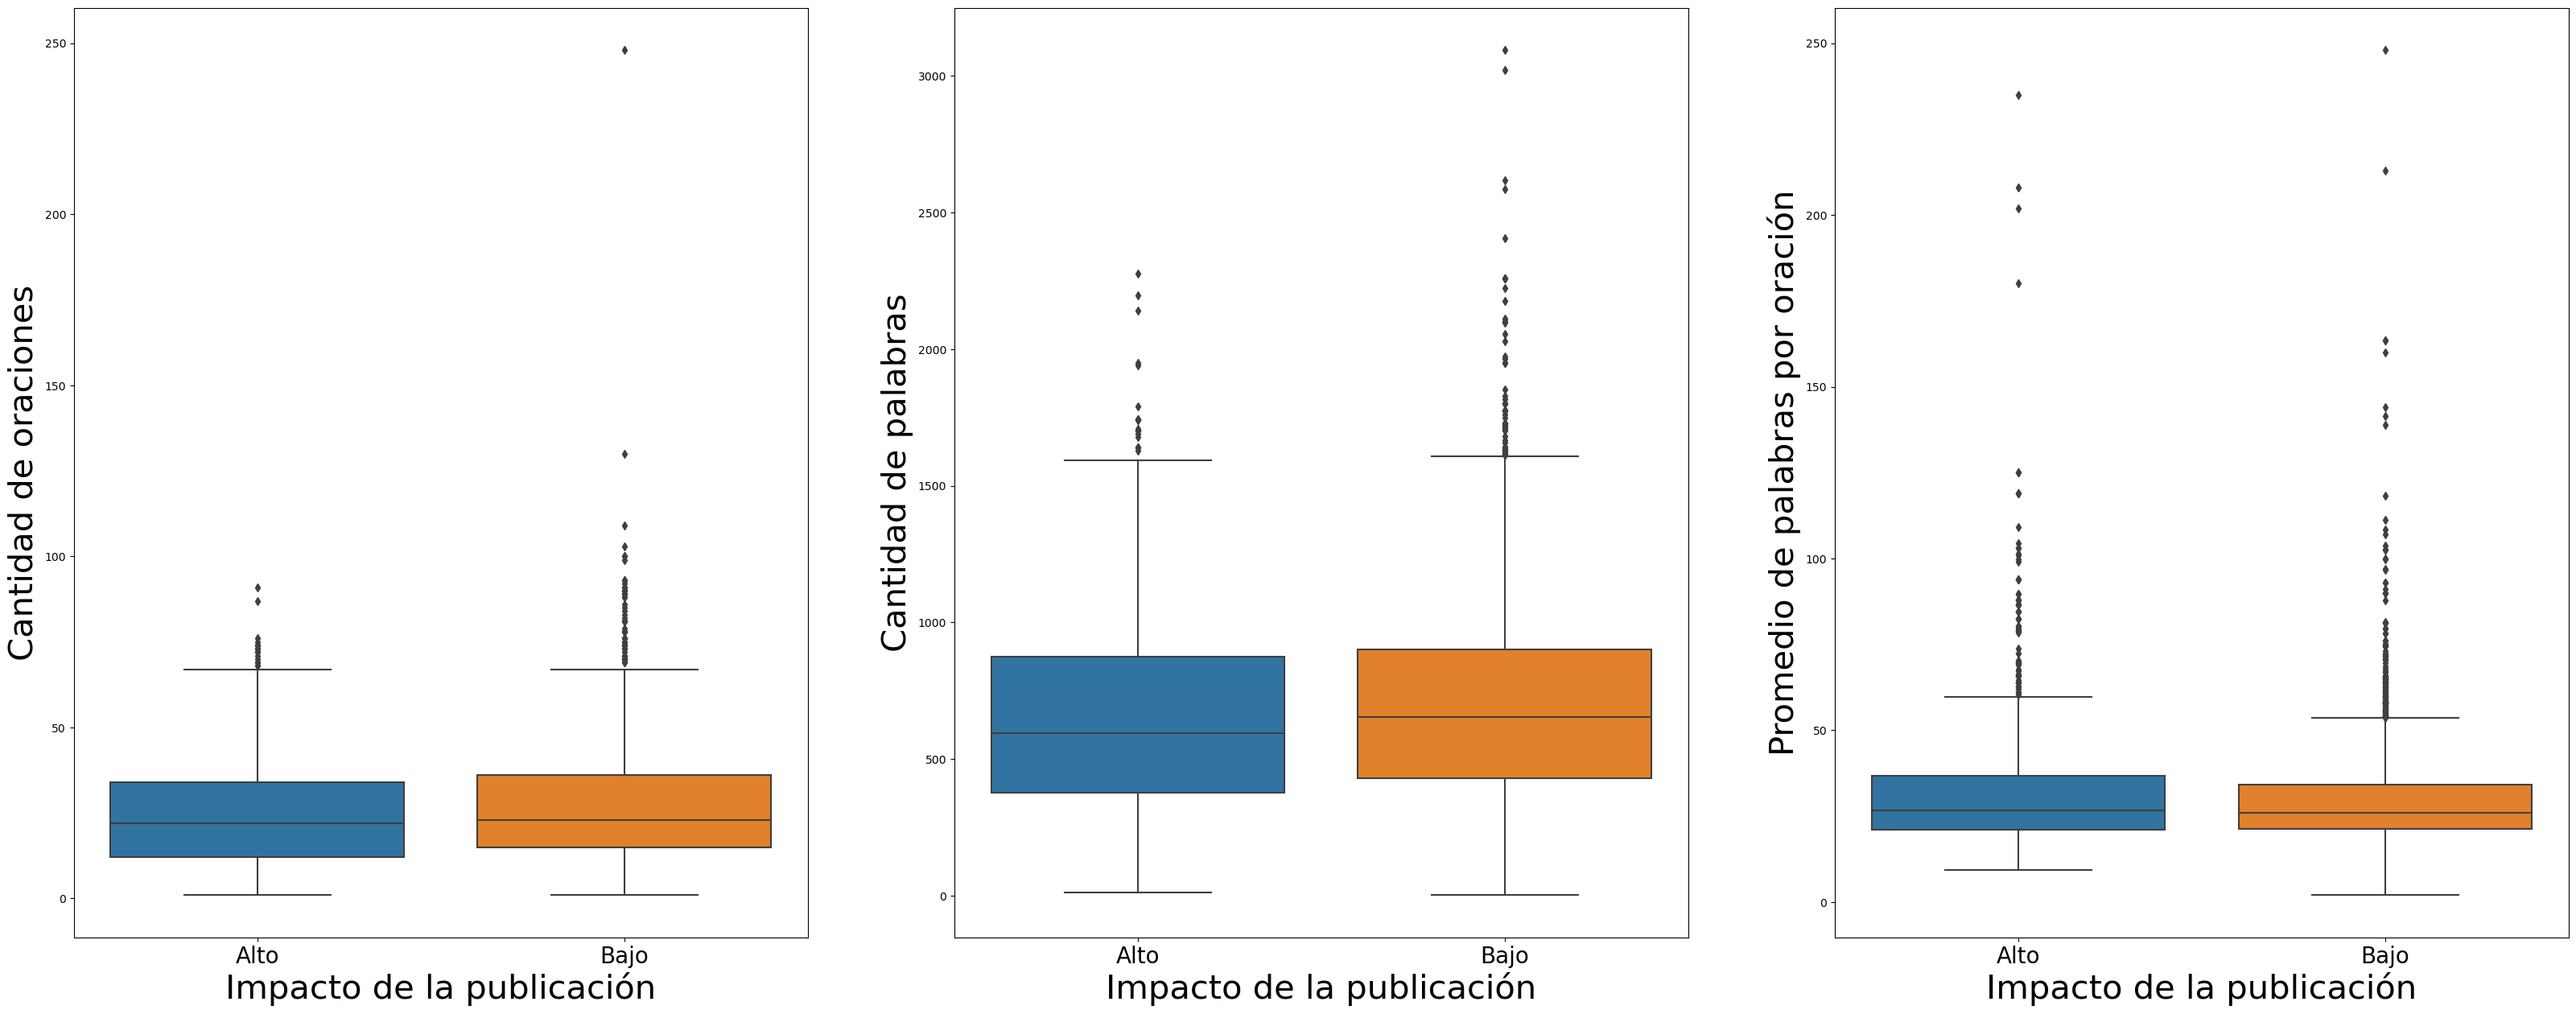

In [ ]:

f, axs = plt.subplots(1, 3, figsize=(40, 15), gridspec_kw=dict(width_ratios=[5, 5, 5]))
plt.xticks([0,1], labels=["Alto", "Bajo"])
axs[0].set_xlabel("Impacto de la publicación", fontsize=30)
axs[1].set_xlabel("Impacto de la publicación", fontsize=30)
axs[2].set_xlabel("Impacto de la publicación", fontsize=30)
axs[0].set_ylabel("Cantidad de oraciones", fontsize=30)
axs[1].set_ylabel("Cantidad de palabras", fontsize=30)
axs[2].set_ylabel("Promedio de palabras por oración", fontsize=30)


alto = df_texto_alto["cantidad_oraciones"]
bp1 = sns.boxplot(data=[df_texto_alto["cantidad_oraciones"], df_texto_bajo["cantidad_oraciones"]], ax=axs[0])
bp2 = sns.boxplot(data=[df_texto_alto["cantidad_palabras"], df_texto_bajo["cantidad_palabras"]], ax=axs[1])
bp3 = sns.boxplot(data=[df_texto_alto["promedio_palabras_oracion"], df_texto_bajo["promedio_palabras_oracion"]], ax=axs[2])

bp1.set_xticks([0, 1], labels=["Alto", "Bajo"], fontsize = 20)
bp2.set_xticks([0, 1], labels=["Alto", "Bajo"], fontsize = 20)
bp3.set_xticks([0, 1], labels=["Alto", "Bajo"], fontsize = 20)

### No se observan grandes diferencias en cuanto a la cantidad de oraciones, la cantidad de palabras y el promedio de palabras por oración entre los 3 grupos de publicaciones de empleo.

## Análisis de unigramas más frecuentes usando CountVectorizer

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
#Creamos una función para calcular las 20 palabras más frecuentes en los textos de alto impacto y en los de bajo impacto.
def get_top_n_words(corpus, n, k):
    vec = CountVectorizer(ngram_range=(k, k), stop_words="english")
    bag_of_words = vec.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

In [ ]:
top_20_words_Alto = get_top_n_words(df[df["impacto"]==1]["description"], 20, 1)
top_20_words_Bajo = get_top_n_words(df[df["impacto"]==0]["description"], 20, 1)


In [ ]:
top_20_words_Alto = pd.DataFrame(top_20_words_Alto, columns=["palabras", "conteo"])
top_20_words_Bajo = pd.DataFrame(top_20_words_Bajo, columns=["palabras", "conteo"])


Text(0, 0.5, 'Frecuencia de palabras')

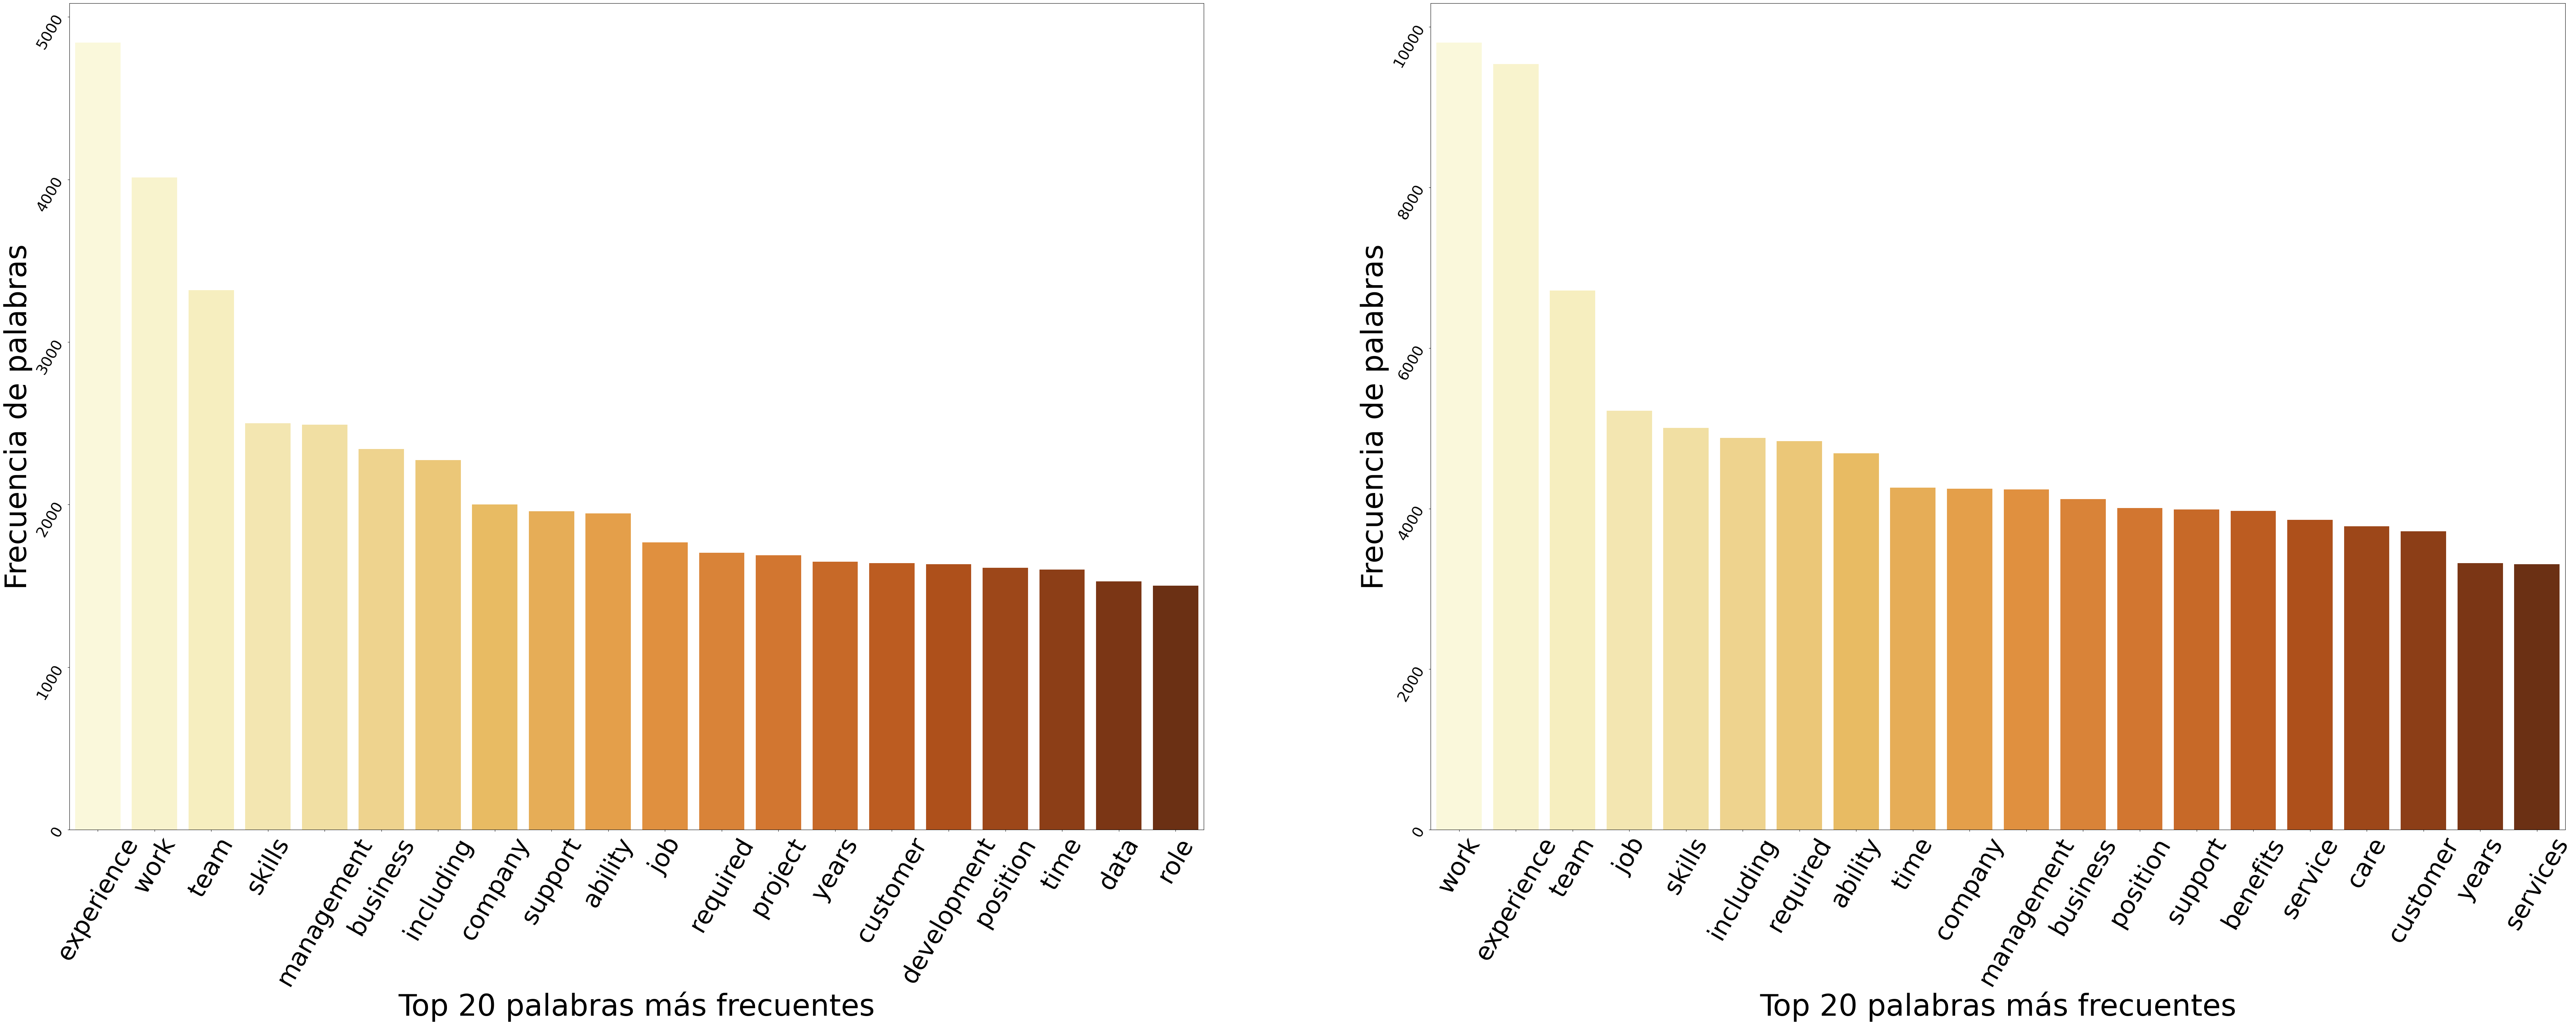

In [ ]:


f, axs = plt.subplots(1, 2, figsize=(90, 30), gridspec_kw=dict(width_ratios=[5, 5]))

axs[0].tick_params(rotation=60)
axs[1].tick_params(rotation=60)


barplot1 = sns.barplot(data=top_20_words_Alto, x=top_20_words_Alto["palabras"], y=top_20_words_Alto["conteo"], palette="YlOrBr", ax=axs[0])
barplot2 = sns.barplot(data=top_20_words_Bajo, x=top_20_words_Bajo["palabras"], y=top_20_words_Bajo["conteo"], palette="YlOrBr", ax=axs[1])
barplot1.set_xlabel("Top 20 palabras más frecuentes", fontsize=60)
barplot1.set_ylabel("Frecuencia de palabras", fontsize=60)
barplot2.set_xlabel("Top 20 palabras más frecuentes", fontsize=60)
barplot2 .set_ylabel("Frecuencia de palabras", fontsize=60)

In [ ]:
# Función que permite encontrar palabras dentro del top 20 de un determinado grupo que no se repitan en el top 20 de otro grupo
def encontrar_elementos_unicos(lista_1, lista_2):
    lista_1 = list(lista_1)
    lista_2 = list(lista_2)



    resultado = []
    for item in lista_1:
        if item not in lista_2:
                 resultado.append(item)
        else:
            continue

    return resultado


In [ ]:
elementos_unicos_alto = encontrar_elementos_unicos(top_20_words_Alto["palabras"], top_20_words_Bajo["palabras"])
print(elementos_unicos_alto)

['project', 'development', 'data', 'role']


In [ ]:
encontrar_elementos_unicos(top_20_words_B["palabras"], top_20_words_A["palabras"], top_20_words_M["palabras"])

[]

In [ ]:
elementos_unicos_bajo = encontrar_elementos_unicos(top_20_words_Bajo["palabras"], top_20_words_Alto["palabras"])
print(elementos_unicos_bajo)

['benefits', 'service', 'care', 'services']


### Observamos que dentro de las 20 elementos más frecuentes en publicaciones de impacto alto y publicaciones de impacto bajo la mayoría de las palabras son palabras compartidas. Sin embargo hay algunas que no se comparten: en el caso de las publicaciones de impacto alto observamos que dentro de su top 20 hay palabras como "proyecto" y "desarrollo" que no estan dentro del top 20 de las publicaciones de bajo impacto. Esto nos podría indicar que la persepectiva del futuro y el crecimiento profesional es algo que atrae a una person en busca de empleo. También aparece la palabra "data", lo cual nos podría indicar que el rubro del análisis de datos/ingeniería de datos es uno de los más buscados.

## Análisis de trigramas más frecuentes

In [ ]:
top_20_words_Alto_3 = get_top_n_words(df[df["impacto"]==1]["description"], 20, 3)
top_20_words_Bajo_3 = get_top_n_words(df[df["impacto"]==0]["description"], 20, 3)

top_20_words_Alto_3 = pd.DataFrame(top_20_words_Alto_3, columns=["palabras", "conteo"])
top_20_words_Bajo_3 = pd.DataFrame(top_20_words_Bajo_3, columns=["palabras", "conteo"])



Text(3882.2954545454527, 0.5, 'Frecuencia de trigramas')

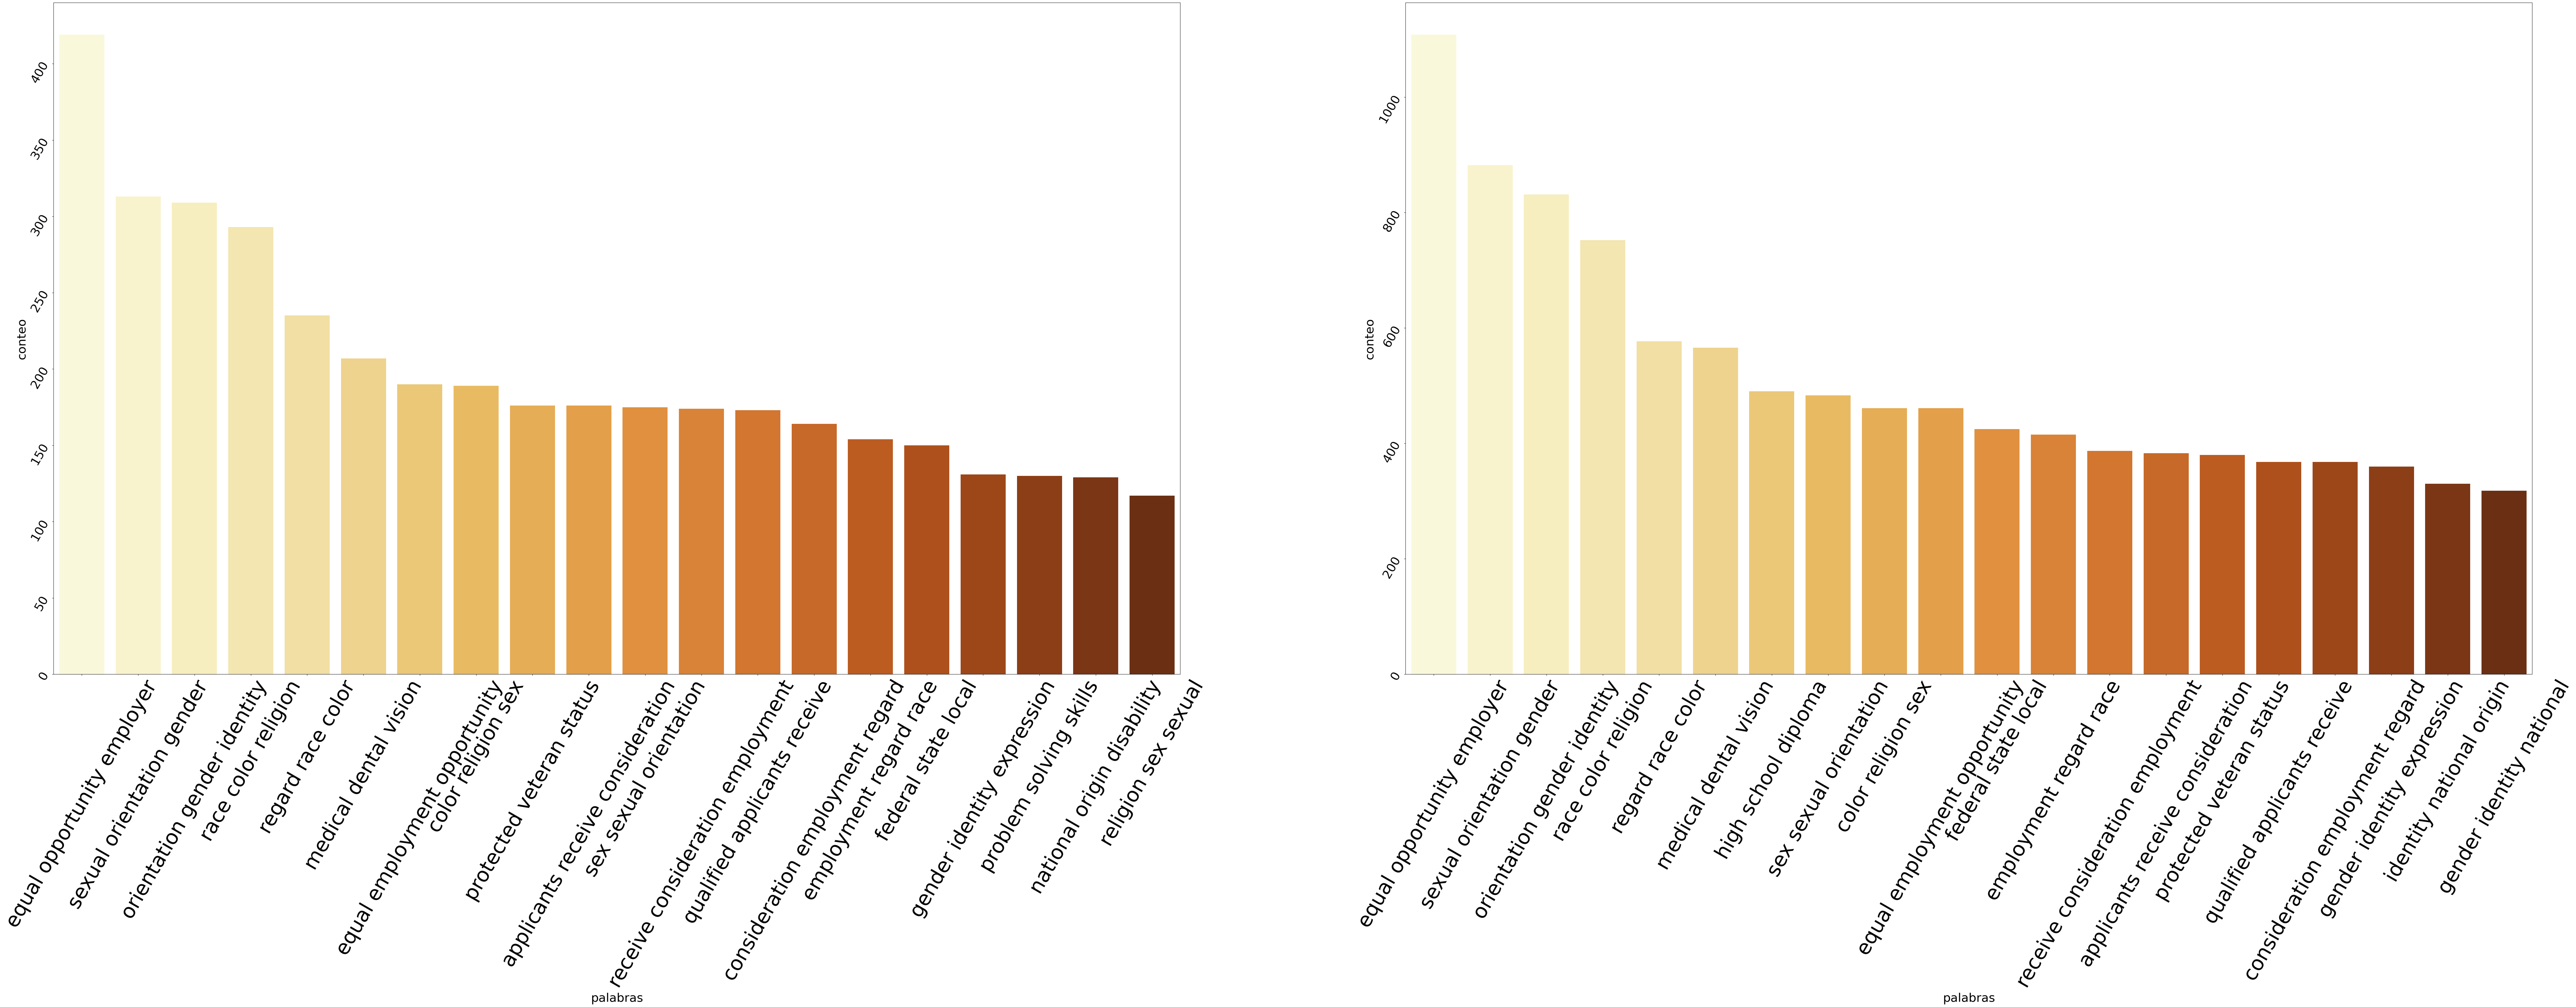

In [ ]:

f, axs = plt.subplots(1, 2, figsize=(110, 30), gridspec_kw=dict(width_ratios=[5, 5]))

axs[0].tick_params(rotation=60)
axs[1].tick_params(rotation=60)


sns.barplot(data=top_20_words_Alto_3, x=top_20_words_Alto_3["palabras"], y=top_20_words_Alto_3["conteo"], palette="YlOrBr", ax=axs[0])
sns.barplot(data=top_20_words_Bajo_3, x=top_20_words_Bajo_3["palabras"], y=top_20_words_Bajo_3["conteo"], palette="YlOrBr", ax=axs[1])

barplot1.set_xlabel("Top 20 trigramas más frecuentes", fontsize=60)
barplot1.set_ylabel("Frecuencia de trigrama", fontsize=60)
barplot2.set_xlabel("Top 20 trigramas más frecuentes", fontsize=60)
barplot2 .set_ylabel("Frecuencia de trigramas", fontsize=60)

In [ ]:
trigramas_unicos_alto = encontrar_elementos_unicos(top_20_words_Alto_3["palabras"], top_20_words_Bajo_3["palabras"])
print(trigramas_unicos_alto)

['problem solving skills', 'national origin disability', 'religion sex sexual']


In [ ]:
trigramas_unicos_bajo = encontrar_elementos_unicos(top_20_words_Bajo_3["palabras"], top_20_words_Alto_3["palabras"])
print(trigramas_unicos_bajo)

['high school diploma', 'identity national origin', 'gender identity national']


### En el análisis de los trigramas observamos que la mayoría de los trigramas más frecuente se comparten entre las publicaciones de alto y bajo impacto. Los trigramas que no se comparten no nos dan demasiada información.

In [ ]:
import re

In [ ]:
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\agus_\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\agus_\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\agus_\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\agus_\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\agus_\AppData\Roaming\nltk_data...
[

True

In [ ]:
#Hacemos una función que toma el primer adjetivo y su sustantivo asociado, luego devuelve (i) el par y (ii) una oración más corta.
def grab_first_pair(sentence):
    words = nltk.word_tokenize(sentence)
    adjectives = [k for k, v in nltk.pos_tag(words) if v == 'JJ']
    if(len(adjectives) > 0):
        shorter = re.findall(adjectives[0] +'.*',sentence)[0]
        words2 = nltk.word_tokenize(shorter)
        nouns = [k for k,v in nltk.pos_tag(words) if v == 'NN']
        if(len(nouns) > 0):
            try:
                shorter = shorter.split(' ', 1)[1]
                return(adjectives[0], nouns[0], shorter)
            except IndexError:
                return(adjectives[0], nouns[0])
    return('', '', '')

# Creamos una funcion que use la anterior para iterar en las oraciones
def grab_all_pairs(sentence):
    pairs = []
    noun = ''
    adj =''
    try:
        while(len(sentence) > 0):
            adj, noun, sentence = grab_first_pair(sentence)
            if(adj != ''):
                pairs.append(adj + ' ' + noun)
        return(pairs)
    except:
        pass

#Creamos una funcion que itere por muchas oraciones luego de tokenizar
def make_pair_list(corpus):
    sentences = nltk.sent_tokenize(corpus)
    pairs = []
    try:
        for sentence in sentences:
            pairs.extend(grab_all_pairs(sentence))
        return(pairs)
    except:
        pass
# Observo un problema en aquellas oraciones en las que el adjetivo se encuentra al final de la oración. Uso una sentencia
# Try/except para ignorar el error. En esos casos se obtiene como valor un nulo.

In [ ]:
# Probamos la funcion con una sola publicacion.
lista_iterable = df[df["impacto"]==1]["description"].reset_index(drop=True)
lista_iterable = pd.DataFrame(lista_iterable)
pairs = make_pair_list(lista_iterable["description"][1])
print(pairs)

['physical IOT', 'actionable data', 'physical safety', 'global power', 'global %', 'll help', 'physical help', 'exciting team', 'Video-Based array', 'public part', 'long company', 'Recent include', 've include', 'experienced role', 'video background', 'complex video', 'video quality', 'other quality', 'mobile team', 'real-time driver', 'video-based driver', 'safe Samsara', 'safe fleet', 'safe reward', 'no-fault exonerate', 'global world', 'new range', 'scalable mature', 'physical innovation', 'life-long learner', 'ambitious learner', 'wide Samsarian', 'rare range', 'independent closeness', 'advanced role', 'objective video', 'on-device video', 'new video', 'new product.Collaborate', 'critical device', 'mobile web', 'cultural features.Champion', 'Long Team', 'new Team', 'Minimum role', 'ideal candidate', 'silicon Expertise', 'objective Familiarity', 'audio etc.Familiarity', 'plus.Demonstrated quality', 'dynamic ability', 's Philosophy', 's Compensation', 's Philosophy', 's compensation'

In [ ]:
# Usamos la función en todas las publicaciones de impacto alto.
pairs_impacto_alto = []
errores_alto = 0
for i in range(len(df[df["impacto"]==1]["description"])):
    try:
        lista_iterable = df[df["impacto"]==1]["description"].reset_index(drop=True)
        lista_iterable = pd.DataFrame(lista_iterable)
        pairs = make_pair_list(lista_iterable["description"][i])
        pairs_impacto_alto += pairs
    except:
        errores_alto += 1
        pass

In [ ]:
print([len(df[df["impacto"]==1]["description"]), errores_alto, len(df[df["impacto"]==1]["description"]) - errores_alto])
# De las 1447 publicaciones de impacto alto, en 481 hubo un error, quedando analizadas 966.

[1447, 481, 966]


In [ ]:
errores_bajo = 0
pairs_impacto_bajo = []
for i in range(len(df[df["impacto"]==0]["description"])):
    try:
        lista_iterable = df[df["impacto"]==0]["description"].reset_index(drop=True)
        lista_iterable = pd.DataFrame(lista_iterable)
        pairs = make_pair_list(lista_iterable["description"][i])
        pairs_impacto_bajo += pairs
    except:
        errores_bajo += 1
        pass

In [ ]:
print([len(df[df["impacto"]==0]["description"]), errores_bajo, len(df[df["impacto"]==0]["description"]) - errores_bajo])
# De las 3198 publicaciones de impacto bajo, en 1235 hubo un error, quedando analizadas 1963.

[3198, 1235, 1963]


In [ ]:
from wordcloud import WordCloud

In [ ]:
pairs_impacto_alto[0].replace(" ", "-")

'potential-impact'

In [ ]:
# Creo una lista con los pares sustantivo-adjetivo como elementos.
word_cloud_text_alto = []
for i in range(len(pairs_impacto_alto)):
    x = pairs_impacto_alto[i].replace(" ", "-")
    word_cloud_text_alto.append(x)

word_cloud_text_bajo = []
for i in range(len(pairs_impacto_bajo)):
    x = pairs_impacto_bajo[i].replace(" ", "-")
    word_cloud_text_bajo.append(x)



In [ ]:
# Creo una función apra generar un diccionario de frecuencias.
def CountFrequency(my_list):


    freq = {}
    for item in my_list:
        if (item in freq):
            freq[item] += 1
        else:
            freq[item] = 1

    return freq

In [ ]:
# Creo un diccionario de frecuencias para la lista de pares de sustantivos-adjetivos.
dict_frecuencias_alto = CountFrequency(word_cloud_text_alto)
dict_frecuencias_bajo = CountFrequency(word_cloud_text_bajo)

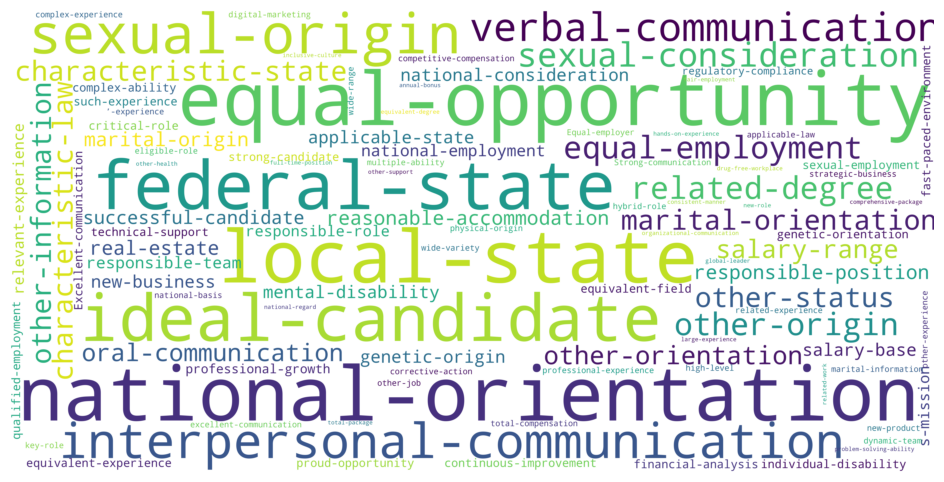

In [ ]:
wordcloud = WordCloud(
    max_font_size=100,
    max_words=100,
    background_color="white",
    scale=10,
    width=800,
    height=400,
    collocations=False
).generate_from_frequencies(dict_frecuencias_alto)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

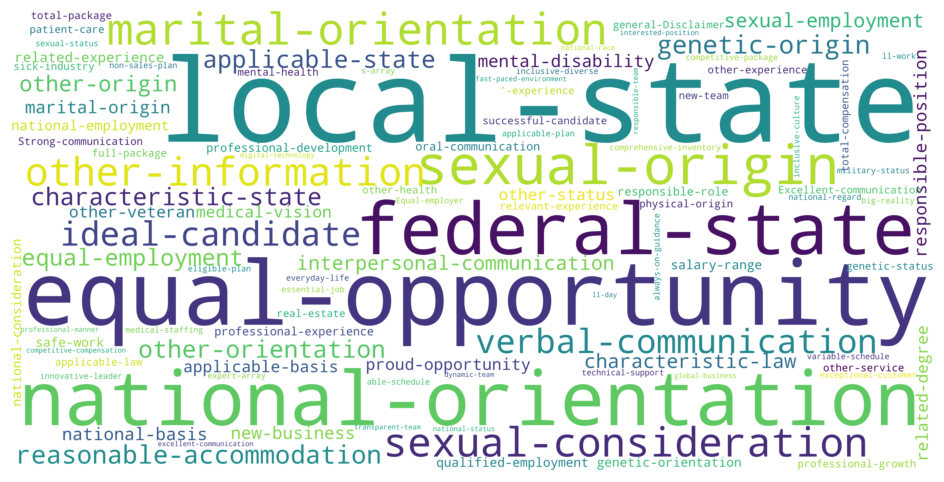

In [ ]:
wordcloud = WordCloud(
    max_font_size=100,
    max_words=100,
    background_color="white",
    scale=10,
    width=800,
    height=400,
    collocations=False
).generate_from_frequencies(dict_frecuencias_bajo)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

## Observamos que las nubes de palabras de los pares sustantivo-adjetivo son distintos entre las publicaciones de impacto alto y bajo. En las publicaciones de impacto alto aparecen con frecuencia conceptos relacionados a la comunicación que no aparecen en las publicaciones de bajo impacto. También aparecen conceptos relacionados con el salario. Estos conceptos podrían ser más atractivos para aquel que busca un empleo y por lo tanto podrían explicar el impacto alto de estas publicaciones.

## Modelo de ML clásico:

Considerando el análisis usando herramientas de NLP reveló que existen ciertas diferencias entre el contenido las pubilcaciones de impacto alto con respecto a las de bajo impacto, planteo usar Word Embeddings para trasnformar las publicaciones de emepleo en vectores que reflejen el contexto de las palabras para luego usar un modelo de Random Forest que permita clasificar el impacto de la publicación en función del análisis de congtenido de su texto.

In [ ]:
import nltk
nltk.download('all')


In [ ]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

In [ ]:
import gensim.downloader
from nltk import word_tokenize

Uso un modelo de Words Embeddings pre-entrenado

In [ ]:
glove_vectors = gensim.downloader.load('word2vec-google-news-300')


In [ ]:
#Genero la matriz de vectores

In [ ]:
review_embeddings = []

for each_review in df['description']:
    review_average = np.zeros(glove_vectors.vector_size)
    count_val = 0

    for each_word in word_tokenize(each_review):

        # Cambiar a "if True" para remover stopwords del promedio de embeddings
        if True:
            if(each_word.lower() in stop_words):
                print(each_word.lower())
                continue

        if(each_word.lower() in glove_vectors):
            review_average += glove_vectors[each_word.lower()]
            count_val += 1

    review_embeddings.append(list(review_average/count_val))

In [ ]:
embedding_data = pd.DataFrame(review_embeddings)
embedding_data = embedding_data.fillna(0)

Divido el dataset en entrenamiento y testeo

In [ ]:
X_train_embed, X_test_embed, y_train_embed, y_test_embed =  train_test_split(
    embedding_data,
    df["impacto"],
    test_size=0.2,
    random_state=0
)

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold
from sklearn.ensemble import RandomForestClassifier

Uso un modelo de Random Forest con optimización de hiperparametros usando GridSearch

In [ ]:
param_grid = {
    'n_estimators': [6, 7, 8],
    'max_depth': [12, 13, 14]
}

clf = RandomForestClassifier(random_state=42)
S_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(clf, param_grid, cv=S_kfold, scoring='recall', return_train_score=True, verbose=3)
grid_search.fit(X_train_embed,  y_train_embed)
best_params = grid_search.best_params_
print("Mejores hiperparámetros:", best_params)

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn import metrics

In [ ]:
best_estimator = grid_search.best_estimator_
y_pred = best_estimator.predict(X_test_embed)
cm4= confusion_matrix(y_test_embed, y_pred)
print(cm4)
print(metrics.classification_report(y_test_embed, y_pred))

## Conclusión: A través de la optimización de hiperparámetros y el algoritmo de clasificación RandomForest fue posible obtener un modelo de predicción con u valor de accuracy relativamente aceptable. Se observa que el modelo predice mejor la categoría 0 (impacto bajo) que la categoría 1 (impacto alto). Esto se puede deber a que las variables target estan desbalanceadas y por lo tanto aprende mejor de la variable que está más representada. A futuro se podría emplear alguna técnica para balancear las variables antes de usar el modelo como por ejemplo SMOTE.